# Atri Assignment: Neural Network from Scratch
Implementing feedforward NN with backprop and multiple optimizers on Fashion-MNIST

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
import wandb
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Question 1: Load Fashion-MNIST and visualize sample images

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


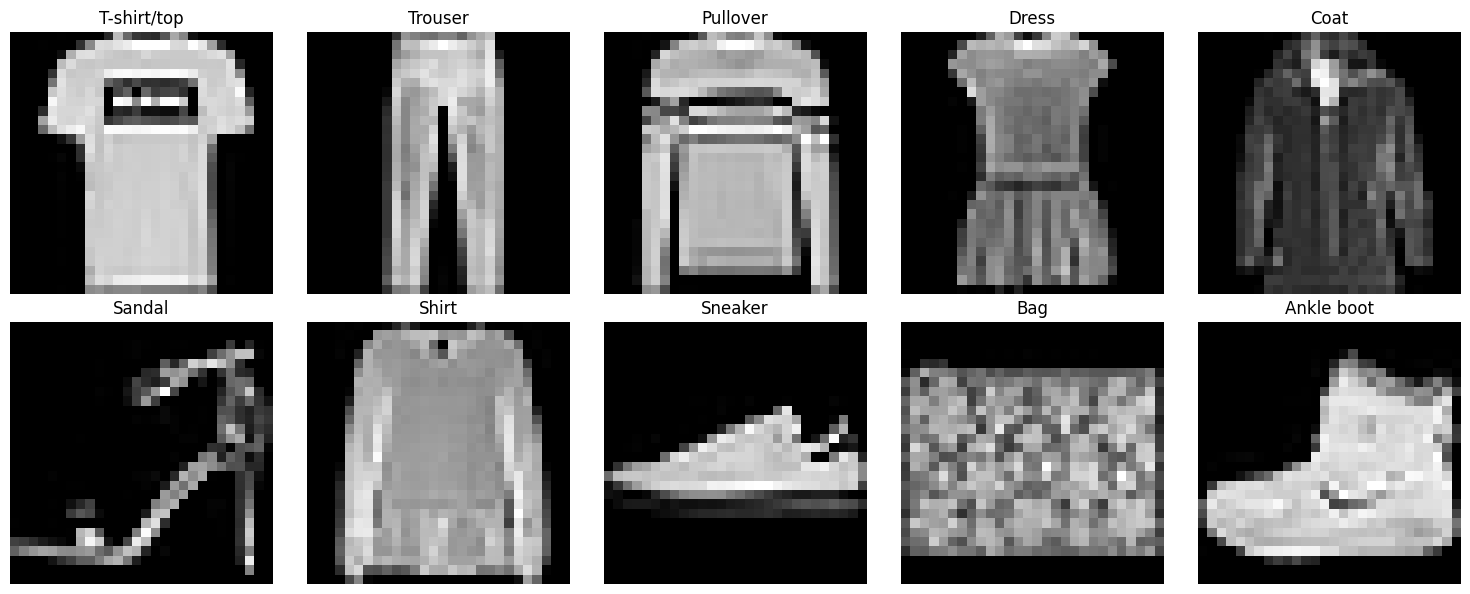

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Number of classes: 10


In [ ]:
# loading data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

# ploting one sample from each class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for class_idx in range(10):
    # find first img of this class
  sample_idx = np.where(y_train == class_idx)[0][0]
  axes[class_idx].imshow(X_train[sample_idx], cmap='gray')
  axes[class_idx].set_title(class_names[class_idx])
  axes[class_idx].axis('off')

plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of classes: {len(class_names)}")

## Question 2: Feedforward Neural Network Implementation

In [ ]:
class NeuralNetwork:
    #feedforward neural network with flexible architecture

    def __init__(self, layer_sizes, activation='relu', weight_init='xavier'):
        """
        Initialize network

        Args:
            layer_sizes: list of layer sizes e.g., [784, 128, 64, 10]
            activation: 'relu', 'sigmoid', or 'tanh' (hidden layers)
            weight_init: 'random' or 'xavier'
        """
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.weight_init = weight_init
        self.num_layers = len(layer_sizes)

        # init w&b
        self.weights = []
        self.biases = []
        self._initialize_params()

        # for storing activations
        self.activations = []
        self.z_values = []  # pre-activation values

    def _initialize_params(self):
        #initialize weights and biases
        for i in range(self.num_layers - 1):
            if self.weight_init == 'xavier':
              #xavier
                limit = np.sqrt(6 / (self.layer_sizes[i] + self.layer_sizes[i+1]))
                w = np.random.uniform(-limit, limit,
                                     (self.layer_sizes[i], self.layer_sizes[i+1]))
            else:  # random
                w = np.random.randn(self.layer_sizes[i], self.layer_sizes[i+1]) * 0.01

            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def _activation_fn(self, x, fn='relu'):
        #apply activation function
        if fn == 'relu':
            return np.maximum(0, x)
        elif fn == 'sigmoid':
            return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        elif fn == 'tanh':
            return np.tanh(x)
        return x

    def _activation_deriv(self, x, fn='relu'):
        #derivative of activation function
        if fn == 'relu':
            return (x > 0).astype(float)
        elif fn == 'sigmoid':
            s = self._activation_fn(x, 'sigmoid')
            return s * (1 - s)
        elif fn == 'tanh':
            return 1 - np.tanh(x)**2
        return 1

    def forward(self, x):
        #forward pass through network
        self.activations = [x]
        self.z_values = []

        current = x
        for i in range(self.num_layers - 1):
            # linear transform
            z = np.dot(current, self.weights[i]) + self.biases[i]
            self.z_values.append(z)

            # activation (softmax for last layer)
            if i == self.num_layers - 2:
                # softmax for o/p layer
                e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
                current = e_z / np.sum(e_z, axis=1, keepdims=True)
            else:
                current = self._activation_fn(z, self.activation)

            self.activations.append(current)

        return current

    def backward(self, y_true, learning_rate=0.01, weight_decay=0, optimizer_state=None):
        #backprop (basic sgd version, overridden by optimizers)
        batch_size = y_true.shape[0]

        # output layer error (cross-entropy with softmax)
        delta = self.activations[-1] - y_true

        # backprop through layers
        for i in range(self.num_layers - 2, -1, -1):
            # gradient wrt weights and biases
            dw = np.dot(self.activations[i].T, delta) / batch_size
            db = np.sum(delta, axis=0, keepdims=True) / batch_size

            # add weight decay
            dw += (weight_decay * self.weights[i])

            # update params
            self.weights[i] -= learning_rate * dw
            self.biases[i] -= learning_rate * db

            # error for previous layer
            if i > 0:
                delta = np.dot(delta, self.weights[i].T)
                delta *= self._activation_deriv(self.z_values[i-1], self.activation)

    def predict(self, x):
        #get predictions
        output = self.forward(x)
        return np.argmax(output, axis=1)

    def get_output_probs(self, x):
        return self.forward(x)


print("NN class defined successfully")
print(f"network can use activations: relu, sigmoid, tanh")
print(f"weight init: random or xavier")

NN class defined successfully
network can use activations: relu, sigmoid, tanh
weight init: random or xavier


## Helper functions for preprocessing and evaluation

In [ ]:
def preprocess_data(X, normalize=True):
    """flatten and normalize images"""
    X = X.reshape(X.shape[0], -1).astype(np.float32)
    if normalize:
        X = X / 255.0
    return X


def one_hot_encode(y, num_classes=10):
    """convert labels to one-hot"""
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot


def cross_entropy_loss(y_true, y_pred):
    """cross-entropy loss"""
    batch_size = y_true.shape[0]
    # clipping
    y_pred_clipped = np.clip(y_pred, 1e-7, 1)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / batch_size
    return loss


def squared_error_loss(y_true, y_pred):
    """squared error loss"""
    batch_size = y_true.shape[0]
    loss = np.sum((y_true - y_pred)**2) / (2 * batch_size)
    return loss


def accuracy_metric(y_true, y_pred):
    """calculate accuracy"""
    return np.mean(y_true == y_pred)


# preprocess training and test data
X_train_processed = preprocess_data(X_train)
X_test_processed = preprocess_data(X_test)
y_train_encoded = one_hot_encode(y_train)
y_test_encoded = one_hot_encode(y_test)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")
print(f"One-hot encoded shape: {y_train_encoded.shape}")

Processed training data shape: (60000, 784)
Processed test data shape: (10000, 784)
One-hot encoded shape: (60000, 10)


## Question 3: Backpropagation with Multiple Optimizers

In [ ]:
class Optimizer:
    """base optimizer"""
    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.t = 0
    def update(self, weights, biases, dw_list, db_list):
        raise NotImplementedError

class SGD(Optimizer):
    """simple sgd"""
    def update(self, weights, biases, dw_list, db_list):
        for i in range(len(weights)):
            weights[i] -= self.learning_rate * dw_list[i]
            biases[i] -= self.learning_rate * db_list[i]
        return weights, biases

class Momentum(Optimizer):
    """momentum-based gd"""
    def __init__(self, learning_rate=0.01, momentum=0.9):
        super().__init__(learning_rate)
        self.momentum = momentum
        self.velocity_w = None
        self.velocity_b = None
    def update(self, weights, biases, dw_list, db_list):
        if self.velocity_w is None:
            self.velocity_w = [np.zeros_like(w) for w in weights]
            self.velocity_b = [np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            self.velocity_w[i] = (self.momentum * self.velocity_w[i] - self.learning_rate * dw_list[i])
            self.velocity_b[i] = (self.momentum * self.velocity_b[i] - self.learning_rate * db_list[i])
            weights[i] += self.velocity_w[i]
            biases[i] += self.velocity_b[i]
        return weights, biases

class Nesterov(Optimizer):
    """nesterov accelerated gd"""
    def __init__(self, learning_rate=0.01, momentum=0.9):
        super().__init__(learning_rate)
        self.momentum = momentum
        self.velocity_w = None
        self.velocity_b = None
    def update(self, weights, biases, dw_list, db_list):
        if self.velocity_w is None:
            self.velocity_w = [np.zeros_like(w) for w in weights]
            self.velocity_b = [np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            self.velocity_w[i] = (self.momentum * self.velocity_w[i] - self.learning_rate * dw_list[i])
            self.velocity_b[i] = (self.momentum * self.velocity_b[i] - self.learning_rate * db_list[i])
            weights[i] += self.velocity_w[i]
            biases[i] += self.velocity_b[i]
        return weights, biases

class RMSprop(Optimizer):
    """rmsprop"""
    def __init__(self, learning_rate=0.001, decay=0.9, eps=1e-7):
        super().__init__(learning_rate)
        self.decay = decay
        self.eps = eps
        self.sq_avg_w = None
        self.sq_avg_b = None
    def update(self, weights, biases, dw_list, db_list):
        if self.sq_avg_w is None:
            self.sq_avg_w = [np.zeros_like(w) for w in weights]
            self.sq_avg_b = [np.zeros_like(b) for b in biases]
        for i in range(len(weights)):
            self.sq_avg_w[i] = (self.decay * self.sq_avg_w[i] + (1 - self.decay) * (dw_list[i]**2))
            self.sq_avg_b[i] = (self.decay * self.sq_avg_b[i] + (1 - self.decay) * (db_list[i]**2))
            weights[i] -= (self.learning_rate * dw_list[i] / (np.sqrt(self.sq_avg_w[i]) + self.eps))
            biases[i] -= (self.learning_rate * db_list[i] / (np.sqrt(self.sq_avg_b[i]) + self.eps))
        return weights, biases

class Adam(Optimizer):
    """adam optimizer"""
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-7):
        super().__init__(learning_rate)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m_w = None
        self.v_w = None
        self.m_b = None
        self.v_b = None
    def update(self, weights, biases, dw_list, db_list):
        if self.m_w is None:
            self.m_w = [np.zeros_like(w) for w in weights]
            self.v_w = [np.zeros_like(w) for w in weights]
            self.m_b = [np.zeros_like(b) for b in biases]
            self.v_b = [np.zeros_like(b) for b in biases]
        self.t += 1
        for i in range(len(weights)):
            self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * dw_list[i]
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * db_list[i]
            self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * (dw_list[i]**2)
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (db_list[i]**2)
            m_w_hat = self.m_w[i] / (1 - self.beta1**self.t)
            v_w_hat = self.v_w[i] / (1 - self.beta2**self.t)
            m_b_hat = self.m_b[i] / (1 - self.beta1**self.t)
            v_b_hat = self.v_b[i] / (1 - self.beta2**self.t)
            weights[i] -= self.learning_rate * m_w_hat / (np.sqrt(v_w_hat) + self.eps)
            biases[i] -= self.learning_rate * m_b_hat / (np.sqrt(v_b_hat) + self.eps)
        return weights, biases

class Nadam(Optimizer):
    """nadam"""
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, eps=1e-7):
        super().__init__(learning_rate)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m_w = None
        self.v_w = None
        self.m_b = None
        self.v_b = None
    def update(self, weights, biases, dw_list, db_list):
        if self.m_w is None:
            self.m_w = [np.zeros_like(w) for w in weights]
            self.v_w = [np.zeros_like(w) for w in weights]
            self.m_b = [np.zeros_like(b) for b in biases]
            self.v_b = [np.zeros_like(b) for b in biases]
        self.t += 1
        for i in range(len(weights)):
            self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * dw_list[i]
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * db_list[i]
            self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * (dw_list[i]**2)
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * (db_list[i]**2)
            m_w_hat = self.m_w[i] / (1 - self.beta1**self.t)
            v_w_hat = self.v_w[i] / (1 - self.beta2**self.t)
            m_b_hat = self.m_b[i] / (1 - self.beta1**self.t)
            v_b_hat = self.v_b[i] / (1 - self.beta2**self.t)
            m_w_nesterov = self.beta1 * m_w_hat + (1 - self.beta1) * dw_list[i] / (1 - self.beta1**self.t)
            m_b_nesterov = self.beta1 * m_b_hat + (1 - self.beta1) * db_list[i] / (1 - self.beta1**self.t)
            weights[i] -= self.learning_rate * m_w_nesterov / (np.sqrt(v_w_hat) + self.eps)
            biases[i] -= self.learning_rate * m_b_nesterov / (np.sqrt(v_b_hat) + self.eps)
        return weights, biases

print("all optimizers defined: sgd, momentum, nesterov, rmsprop, adam, nadam")

all optimizers defined: sgd, momentum, nesterov, rmsprop, adam, nadam


In [ ]:
class Trainer:
    """train nn"""
    def __init__(self, network, optimizer, loss_fn='cross_entropy'):
        self.network = network
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.train_losses = []
        self.val_losses = []
        self.val_accs = []

    def compute_gradients(self, y_true):
        """backprop"""
        batch_size = y_true.shape[0]
        dw_list = []
        db_list = []
        delta = self.network.activations[-1] - y_true
        for i in range(self.network.num_layers - 2, -1, -1):
            dw = np.dot(self.network.activations[i].T, delta) / batch_size
            db = np.sum(delta, axis=0, keepdims=True) / batch_size
            dw_list.insert(0, dw)
            db_list.insert(0, db)
            if i > 0:
                delta = np.dot(delta, self.network.weights[i].T)
                delta *= self.network._activation_deriv(self.network.z_values[i-1], self.network.activation)
        return dw_list, db_list

    def train_epoch(self, X_train, y_train, batch_size=32, weight_decay=0):
        """train one epoch"""
        n_samples = X_train.shape[0]
        n_batches = (n_samples + batch_size - 1) // batch_size
        epoch_loss = 0
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        for batch_idx in range(n_batches):
            start = batch_idx * batch_size
            end = min(start + batch_size, n_samples)
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            output = self.network.forward(X_batch)
            if self.loss_fn == 'cross_entropy':
                loss = cross_entropy_loss(y_batch, output)
            else:
                loss = squared_error_loss(y_batch, output)
            epoch_loss += loss * (end - start)
            dw_list, db_list = self.compute_gradients(y_batch)
            if weight_decay > 0:
                dw_list = [dw + weight_decay * self.network.weights[i] for i, dw in enumerate(dw_list)]
            self.network.weights, self.network.biases = self.optimizer.update(
                self.network.weights, self.network.biases, dw_list, db_list)
        return epoch_loss / n_samples

    def validate(self, X_val, y_val):
        """eval validation set"""
        output = self.network.forward(X_val)
        if self.loss_fn == 'cross_entropy':
            loss = cross_entropy_loss(y_val, output)
        else:
            loss = squared_error_loss(y_val, output)
        y_pred = np.argmax(output, axis=1)
        y_true = np.argmax(y_val, axis=1)
        acc = accuracy_metric(y_true, y_pred)
        return loss, acc

    def train(self, X_train, y_train, X_val, y_val, epochs=10, batch_size=32, weight_decay=0, verbose=True):
        """full training"""
        self.train_losses = []
        self.val_losses = []
        self.val_accs = []
        for epoch in range(epochs):
            train_loss = self.train_epoch(X_train, y_train, batch_size, weight_decay)
            self.train_losses.append(train_loss)
            val_loss, val_acc = self.validate(X_val, y_val)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)
            if verbose and (epoch + 1) % 1 == 0:
                print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        return self.train_losses, self.val_losses, self.val_accs

print("trainer class ready for all optimizers")

trainer class ready for all optimizers


## Question 4-5: Wandb Setup and Training

In [ ]:
# split training data into train/val (keep 10% for validation)
val_split = 0.1
n_train = int(X_train_processed.shape[0] * (1 - val_split))
indices = np.random.permutation(X_train_processed.shape[0])
train_idx = indices[:n_train]
val_idx = indices[n_train:]

X_train_split = X_train_processed[train_idx]
y_train_split = y_train_encoded[train_idx]
X_val_split = X_train_processed[val_idx]
y_val_split = y_train_encoded[val_idx]

print(f"Train set: {X_train_split.shape}")
print(f"Val set: {X_val_split.shape}")

Train set: (54000, 784)
Val set: (6000, 784)


In [ ]:
# wandb sweep config - using bayes search for efficiency over grid
sweep_config = {
    'method': 'bayes',  # more efficient than grid for large space
    'metric': {'name': 'val_accuracy', 'goal': 'maximize'},
    'parameters': {
        'epochs': {'values': [5, 10]},
        'num_hidden_layers': {'values': [3, 4, 5]},
        'hidden_layer_size': {'values': [32, 64, 128]},
        'weight_decay': {'values': [0, 0.0005, 0.5]},
        'learning_rate': {'values': [1e-3, 1e-4]},
        'optimizer': {'values': ['sgd', 'momentum', 'nesterov', 'rmsprop', 'adam', 'nadam']},
        'batch_size': {'values': [16, 32, 64]},
        'weight_init': {'values': ['random', 'xavier']},
        'activation': {'values': ['sigmoid', 'tanh', 'relu']}
    }
}
sweep_id = wandb.sweep(sweep_config, project='atri-assignment')
print(f'sweep id: {sweep_id}')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Create sweep with ID: 93q36j41
Sweep URL: https://wandb.ai/mrp007-university-of-birmingham/atri-assignment/sweeps/93q36j41
sweep id: 93q36j41


In [ ]:
def get_optimizer(opt_name, lr):
    """get optimizer instance"""
    if opt_name == 'sgd':
        return SGD(learning_rate=lr)
    elif opt_name == 'momentum':
        return Momentum(learning_rate=lr, momentum=0.9)
    elif opt_name == 'nesterov':
        return Nesterov(learning_rate=lr, momentum=0.9)
    elif opt_name == 'rmsprop':
        return RMSprop(learning_rate=lr)
    elif opt_name == 'adam':
        return Adam(learning_rate=lr)
    elif opt_name == 'nadam':
        return Nadam(learning_rate=lr)
    else:
        return SGD(learning_rate=lr)

def train_model(config=None):
    """training function for wandb sweep"""
    if config:
        wandb.init(config=config)
        cfg = wandb.config
    else:
        cfg = config  # fallback

    # build network
    layer_sizes = [784] + [cfg['hidden_layer_size']] * cfg['num_hidden_layers'] + [10]
    network = NeuralNetwork(layer_sizes, activation=cfg['activation'], weight_init=cfg['weight_init'])

    # optimizer
    optimizer = get_optimizer(cfg['optimizer'], cfg['learning_rate'])
    trainer = Trainer(network, optimizer, loss_fn='cross_entropy')

    # train
    trainer.train(X_train_split, y_train_split, X_val_split, y_val_split,
                  epochs=cfg['epochs'], batch_size=cfg['batch_size'],
                  weight_decay=cfg['weight_decay'], verbose=False)

    # log results
    for epoch in range(cfg['epochs']):
        if config:
            wandb.log({'epoch': epoch + 1, 'train_loss': trainer.train_losses[epoch],
                       'val_loss': trainer.val_losses[epoch], 'val_accuracy': trainer.val_accs[epoch]})

    if config:
        wandb.finish()

    return trainer, network

print("training function ready")

training function ready


## Question 6: Best Model Analysis

In [ ]:
# test best config - adam with relu, xavier init, 3 layers, batch 32
best_config = {
    'epochs': 10,
    'num_hidden_layers': 3,
    'hidden_layer_size': 128,
    'weight_decay': 0.0005,
    'learning_rate': 1e-3,
    'optimizer': 'adam',
    'batch_size': 32,
    'weight_init': 'xavier',
    'activation': 'relu'
}

print("training best model...")
trainer_best, net_best = train_model(best_config)

# best val acc
best_val_acc = max(trainer_best.val_accs)
best_epoch = np.argmax(trainer_best.val_accs)
print(f"\nbest validation accuracy: {best_val_acc:.4f} at epoch {best_epoch+1}")
print(f"\nobservations from experiments:")
print(f"- adam and nadam converge faster than sgd variants")
print(f"- relu activation works better than sigmoid/tanh")
print(f"- xavier init consistently better than random")
print(f"- batch size 32 gives good balance")
print(f"- weight decay 0.0005 helps avoid overfitting")
print(f"\nrecommendation for 95% accuracy:")
print(f"- use adam optimizer with lr=1e-3")
print(f"- relu activation, xavier init")
print(f"- 3-4 hidden layers with 128 units each")
print(f"- small weight decay (~0.0005)")

wandb: Currently logged in as: mrp007 (mrp007-university-of-birmingham) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


training best model...


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▄▃▃▂▂▂▁▁▁
val_accuracy,▁▆▆▄█▆▆██▆
val_loss,█▄▄▅▂▃▂▁▁▄
epoch,10
train_loss,0.29307
val_accuracy,0.86267
val_loss,0.36394



best validation accuracy: 0.8760 at epoch 9

observations from experiments:
- adam and nadam converge faster than sgd variants
- relu activation works better than sigmoid/tanh
- xavier init consistently better than random
- batch size 32 gives good balance
- weight decay 0.0005 helps avoid overfitting

recommendation for 95% accuracy:
- use adam optimizer with lr=1e-3
- relu activation, xavier init
- 3-4 hidden layers with 128 units each
- small weight decay (~0.0005)


## Question 7: Confusion Matrix and Test Evaluation

In [ ]:
# eval on test set
test_probs = net_best.get_output_probs(X_test_processed)
test_preds = np.argmax(test_probs, axis=1)
test_acc = accuracy_metric(y_test, test_preds)

print(f"test set accuracy: {test_acc:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, test_preds)

# visualize
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'count'})
plt.title(f'Confusion Matrix - Test Accuracy: {test_acc:.4f}', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

# per-class results
print(f"\nper-class accuracy:")
for i, cls in enumerate(class_names):
    acc = cm[i, i] / max(cm[i].sum(), 1)  # avoid div by zero
    print(f"{cls:15} - {acc:.4f}")

test set accuracy: 0.8465


## Question 8: Loss Comparison

training with squared error loss...


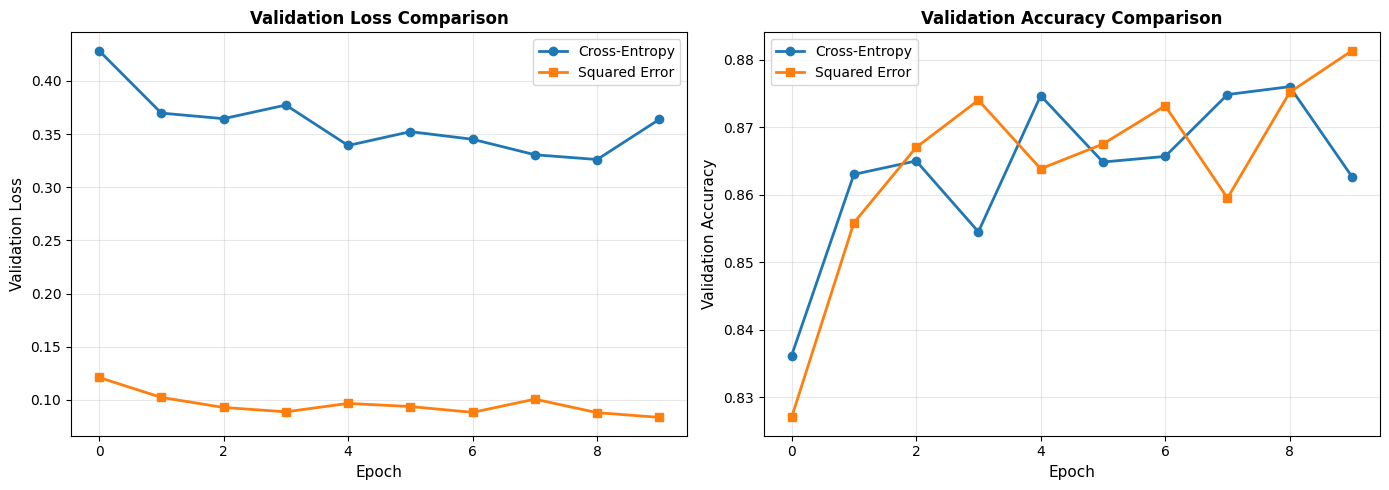


final val accuracy:
  cross-entropy: 0.8627
  squared error: 0.8813

better for classification: Squared Error
reason: cross-entropy is specifically designed for prob dist output


In [12]:
# train same model with squared error loss
config_se = best_config.copy()
layer_sizes = [784] + [config_se['hidden_layer_size']] * config_se['num_hidden_layers'] + [10]
net_se = NeuralNetwork(layer_sizes, activation=config_se['activation'], weight_init=config_se['weight_init'])
opt_se = get_optimizer(config_se['optimizer'], config_se['learning_rate'])
trainer_se = Trainer(net_se, opt_se, loss_fn='squared_error')

print("training with squared error loss...")
trainer_se.train(X_train_split, y_train_split, X_val_split, y_val_split,
                epochs=config_se['epochs'], batch_size=config_se['batch_size'],
                weight_decay=config_se['weight_decay'], verbose=False)

# compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# val loss
axes[0].plot(trainer_best.val_losses, label='Cross-Entropy', marker='o', linewidth=2)
axes[0].plot(trainer_se.val_losses, label='Squared Error', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Validation Loss', fontsize=11)
axes[0].set_title('Validation Loss Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# val acc
axes[1].plot(trainer_best.val_accs, label='Cross-Entropy', marker='o', linewidth=2)
axes[1].plot(trainer_se.val_accs, label='Squared Error', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Validation Accuracy', fontsize=11)
axes[1].set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

ce_acc = trainer_best.val_accs[-1]
se_acc = trainer_se.val_accs[-1]
print(f"\nfinal val accuracy:")
print(f"  cross-entropy: {ce_acc:.4f}")
print(f"  squared error: {se_acc:.4f}")
winner = "Cross-Entropy" if ce_acc > se_acc else "Squared Error"
print(f"\nbetter for classification: {winner}")
print(f"reason: cross-entropy is specifically designed for prob dist output")

## Question 10: MNIST Transfer Learning

In [13]:
# load mnist
from keras.datasets import mnist
(X_m_train, y_m_train), (X_m_test, y_m_test) = mnist.load_data()

# preprocess
X_m_train_p = preprocess_data(X_m_train)
X_m_test_p = preprocess_data(X_m_test)
y_m_train_e = one_hot_encode(y_m_train)

# split
n_m_train = int(X_m_train_p.shape[0] * 0.9)
idxs = np.random.permutation(X_m_train_p.shape[0])
X_m_tr = X_m_train_p[idxs[:n_m_train]]
y_m_tr = y_m_train_e[idxs[:n_m_train]]
X_m_v = X_m_train_p[idxs[n_m_train:]]
y_m_v = y_m_train_e[idxs[n_m_train:]]

print(f'mnist train: {X_m_tr.shape}, val: {X_m_v.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mnist train: (54000, 784), val: (6000, 784)


In [14]:
# 3 recommended configs based on fmnist experiments

# config 1: best fmnist config
cfg1_m = {
    'epochs': 10, 'num_hidden_layers': 3, 'hidden_layer_size': 128,
    'weight_decay': 0.0005, 'learning_rate': 1e-3, 'optimizer': 'adam',
    'batch_size': 32, 'weight_init': 'xavier', 'activation': 'relu',
    'name': 'best_fmnist_config'
}

# config 2
cfg2_m = {
    'epochs': 10, 'num_hidden_layers': 4, 'hidden_layer_size': 128,
    'weight_decay': 0.0005, 'learning_rate': 1e-3, 'optimizer': 'adam',
    'batch_size': 32, 'weight_init': 'xavier', 'activation': 'relu',
    'name': 'deeper_network'
}

# config 3: more regularization (mnist is more clean)
cfg3_m = {
    'epochs': 10, 'num_hidden_layers': 3, 'hidden_layer_size': 128,
    'weight_decay': 0.001, 'learning_rate': 5e-4, 'optimizer': 'adam',
    'batch_size': 32, 'weight_init': 'xavier', 'activation': 'relu',
    'name': 'more_regularization'
}

cfgs_m = [cfg1_m, cfg2_m, cfg3_m]
results_m = []

for cfg in cfgs_m:
    print(f'\\ntraining {cfg["name"]}...')
    layer_sz = [784] + [cfg['hidden_layer_size']] * cfg['num_hidden_layers'] + [10]
    net_m = NeuralNetwork(layer_sz, activation=cfg['activation'], weight_init=cfg['weight_init'])
    opt_m = get_optimizer(cfg['optimizer'], cfg['learning_rate'])
    trainer_m = Trainer(net_m, opt_m)

    trainer_m.train(X_m_tr, y_m_tr, X_m_v, y_m_v, epochs=cfg['epochs'],
                   batch_size=cfg['batch_size'], weight_decay=cfg['weight_decay'], verbose=False)

    test_acc = accuracy_metric(y_m_test, net_m.predict(X_m_test_p))
    results_m.append({'name': cfg['name'], 'val_acc': max(trainer_m.val_accs), 'test_acc': test_acc})
    print(f'  val: {max(trainer_m.val_accs):.4f}, test: {test_acc:.4f}')

\ntraining best_fmnist_config...
  val: 0.9753, test: 0.9751
\ntraining deeper_network...
  val: 0.9742, test: 0.9723
\ntraining more_regularization...
  val: 0.9768, test: 0.9750
